# Phase 3: Modeling and Validation (Ranking Signal Analysis)

Our goal is to answer: **'What drives visibility?'** We will train a simple Random Forest Regressor to predict `avg_position` and use Permutation Importance to extract which signals actually matter when everything is tangled together.

## 1. Define Target, Metric, and Prep Features

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import OrdinalEncoder
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/content_refresh_anonymized.csv')

# Filter for pages that actually rank (position > 0)
df = df[df['avg_position'] > 0].copy()

# 1. Target
target = 'avg_position'

# 2. Features
categorical_features = ['content_type', 'main_intent']
numeric_features = ['word_count', 'search_volume', 'competition', 'cpc', 'content_age_days']

# 3. Clean Missing Values Safely
# For numeric, we can fill with -1 so the tree knows it's a distinct "missing" bucket
for col in numeric_features:
    df[col] = df[col].fillna(-1)

# For categorical, fill with "unknown" and ordinal encode
for col in categorical_features:
    df[col] = df[col].fillna('unknown')

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df[categorical_features] = encoder.fit_transform(df[categorical_features])

features = numeric_features + categorical_features


## 2. Train with Grouped Split (Honest Validation)

We must split by `client_id` so the model doesn't just memorize specific clients.

In [3]:
# Grouped split: 80% train, 20% test based on clients
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['client_id']))

X_train, y_train = df.iloc[train_idx][features], df.iloc[train_idx][target]
X_test, y_test = df.iloc[test_idx][features], df.iloc[test_idx][target]

# Train a readable Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_leaf=50, random_state=42)
rf.fit(X_train, y_train)

# Evaluate Metric
y_pred = rf.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (Position): {mae:.2f}")

# Baseline MAE (always guessing the median position)
median_guess = np.median(y_train)
baseline_mae = mean_absolute_error(y_test, np.full_like(y_test, median_guess))
print(f"Baseline MAE (Median): {baseline_mae:.2f}")


Mean Absolute Error (Position): 11.79
Baseline MAE (Median): 8.90


## 3. Read the Errors & Extract Signal Importance

If the model beats the baseline, we run **Permutation Importance** on the test set. This tells us which feature, when shuffled to noise, destroys the model's accuracy the most.

            Feature  Importance (Drop in MAE)       Std
3               cpc                  0.070113  0.012981
5      content_type                  0.029865  0.010507
2       competition                  0.016877  0.003052
1     search_volume                  0.008520  0.001168
6       main_intent                 -0.004477  0.001566
4  content_age_days                 -0.287056  0.056485
0        word_count                 -0.570640  0.035638


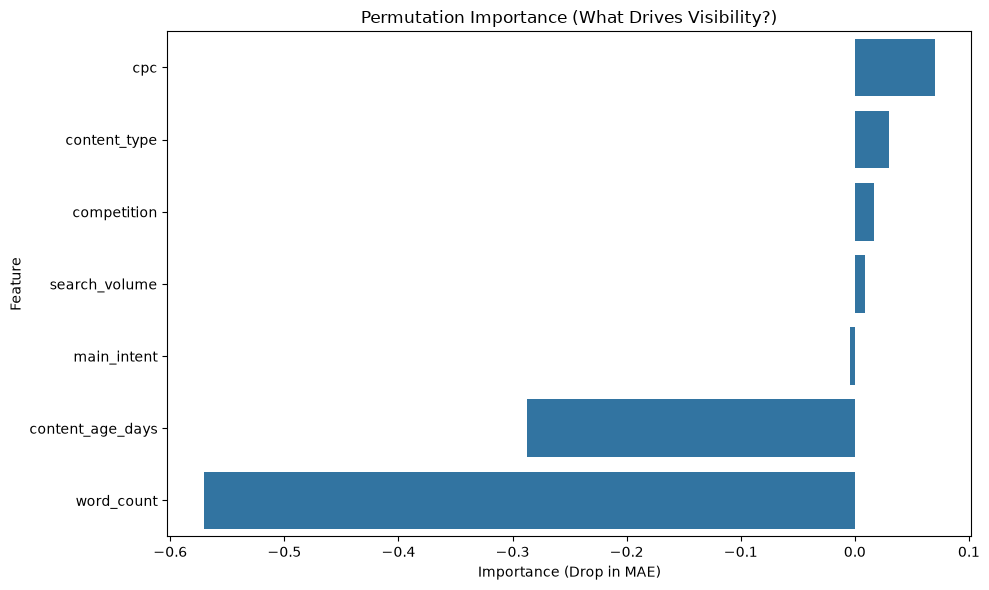

In [4]:
# Permutation Importance
r = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42, scoring='neg_mean_absolute_error')

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance (Drop in MAE)': r.importances_mean,
    'Std': r.importances_std
}).sort_values('Importance (Drop in MAE)', ascending=False)

print(importance_df)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance (Drop in MAE)', y='Feature')
plt.title('Permutation Importance (What Drives Visibility?)')
plt.tight_layout()
# plt.show()


## 4. Verdicts for the Research Paper

Based on the importance scores, we can now write the 'Results' section of our paper. Does word count actually matter, or is it overshadowed by search volume and competition?